# Cryoscope Sandbox

This notebook imports real data obtained from the NUS cryogenic fridge from the Ramsey-style experiment that's used in Cryoscope. The user should run all of the cells until reaching the bottom tab titled 'Run This Cell'. Here one can choose the DPD algorithm to be used on the data, specifying things like the number of filters, filter taps, etc.
This is intended to be used as a playground for trying different things and methods out. 

For the final code, use nus_cryoscope instead.

## Initialising

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cma
from pathlib import Path
from scipy.fft import fft, ifft, fftfreq
from scipy.constants import h, e
from scipy.signal import savgol_filter, lfilter
from scipy.optimize import curve_fit

## Dark Mode

Run this cell if you would like the plots in 'dark mode'.

In [2]:
### Run this cell only if you're using "dark mode"

# svg plots (higher-res)
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png')

plt.rcParams.update({
    'figure.facecolor': '#383838',
    'figure.edgecolor': '#383838',
    'axes.facecolor':   '#383838',
    'axes.edgecolor':   '#DDE2F4',
    'axes.labelcolor':  '#DDE2F4',
    'xtick.color':      '#DDE2F4',
    'ytick.color':      '#DDE2F4',
    'text.color':       '#DDE2F4',
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

## Importing Data

Currently, there are two methods of performing the Cryoscope experiment. Method 1 uses a slick envelope creation trick in order to play AWG BB pulses <13.333ns in duration. 
Method 2 uses standard Keysight programmes and experiments. It is more streamlined and easier to follow but begins collecting data at 13.333ns pulses.

### Method 1 (<13.333 Pulses)


In [4]:
def cryo_meth_1_data():
    """
    Returns the reconstructed magnetic flux (from Method 1) from the Ramsey-style experiment done in Cryoscope 
    by combining the expectation values data obtained, along with the other constants and variable needed for the rest of the analysis.

    Parameters
    -----------
    None.

    Returns
    -----------
    s_avg : array (complex)
        The voltage-to-flux response obtained from the I/Q data.
    taus : array (real)
        The list of pulse durations applied in the Ramsey-style experiment, i.e. the independent variable.
    delta_tau : float
        The duration interval between subsequent pulses that were played in the experiment.
    awg_amp : float
        The amplitude of the BB AWG pulse that was played in the experiment. 
    """

    filename = "XResults_Cryoscope_Method1_0_start_60_shots_amplitude_0.02.npy"
    stem = Path(filename).stem

    awg_amp = float(stem.split("amplitude_")[1])
    start_tau = float(stem.split("Method1_")[1].split("_")[0]) * 10e-10
    tau_shots = int(stem.split("start_")[1].split("_")[0])
    delta_tau = 3.333e-9 # smallest interval possible 
    end_tau = start_tau + tau_shots * delta_tau
    tau_sweep = np.linspace(start_tau, end_tau, tau_shots)

    x_prob = np.load("XResults_Cryoscope_Method1_0_start_60_shots_amplitude_0.02.npy")
    y_prob = np.load("YResults_Cryoscope_Method1_0_start_60_shots_amplitude_0.02.npy")

    min_x = np.min(x_prob)
    max_x = np.max(x_prob)

    norm_x = (x_prob - min_x) / (max_x - min_x)

    min_y = np.min(y_prob)
    max_y = np.max(y_prob)

    norm_y = (y_prob - min_y) / (max_y - min_y)

    plt.plot(tau_sweep * 1e9, norm_x)
    plt.plot(tau_sweep * 1e9, norm_y)
    plt.xlabel("Time [ns]")
    plt.ylabel("State Probability (Normalized)")
    #plt.xlim(0, 100)
    plt.title("Q1 Flux-Ramsey (Normalized)")
    plt.grid()
    plt.legend()
    plt.show()

    expect_x = norm_x * 2 - 1
    expect_y = norm_y * 2 - 1

    s_avg = expect_x + 1j * expect_y


    # if plotting the results, one can un-comment these lines
    """plt.scatter(tau_sweep * 1e9, x_prob, s = 8)
    plt.scatter(tau_sweep * 1e9, y_prob, s = 8)
    plt.xlabel("Time [ns]")
    plt.ylabel("State Probability")
    #plt.xlim(0, 100)
    plt.title("Q1 Flux-Ramsey")
    plt.grid()

    plt.figure(figsize = (8,4))
    plt.plot(tau_sweep / 1e-9, abs(s_avg), '-') 
    plt.xlabel("Delay time [ns]")
    plt.ylabel("Acquired IQ amplitude [arb. units]")
    plt.title("Average Magnitude of S Data From Method 1 of Ramsey Experiment")
    plt.grid(True)
    plt.show()"""

    taus = tau_sweep

    return s_avg, taus, delta_tau, awg_amp

### Method 2 (>=13.333 ns Pulses)

In [4]:
def cryo_meth_2_data():
    """
    Returns the reconstructed magnetic flux (from Method 2) from the Ramsey-style experiment done in Cryoscope 
    by combining the I/Q data obtained along with the other constants and variable needed for the rest of the analysis.

    Parameters
    -----------
    None.

    Returns
    -----------
    s_avg : array (complex)
        The voltage-to-flux response obtained from the I/Q data.
    taus : array (real)
        The list of pulse durations applied in the Ramsey-style experiment, i.e. the independent variable.
    delta_tau : float
        The duration interval between subsequent pulses that were played in the experiment.
    awg_amp : float
        The amplitude of the BB AWG pulse that was played in the experiment. 
    """

    filename = "QData_Cryoscope_Method2_13.3_start_100_shots_amplitude_0.5.npy""NUS Code"
    stem = Path(filename).stem

    awg_amp = float(stem.split("amplitude_")[1])
    start_tau = float(stem.split("Method2_")[1].split("_")[0]) * 10e-10
    tau_shots = int(stem.split("start_")[1].split("_")[0])
    delta_tau = 3.33e-9 # smallest interval possible 
    end_tau = start_tau + tau_shots * delta_tau
    tau_sweep = np.linspace(start_tau, end_tau, tau_shots)

    I = np.load("IData_Cryoscope_Method2_13.3_start_100_shots_amplitude_0.5.npy")
    Q = np.load("QData_Cryoscope_Method2_13.3_start_100_shots_amplitude_0.5.npy")

    s_avg = I + 1j * Q

    # can un-comment these lines to see the plot
    """plt.plot(tau_sweep * 1e9, I, label = 'I Data')
    plt.plot(tau_sweep * 1e9, Q, label = 'Q Data')
    plt.xlabel("Time [ns]")
    plt.ylabel("I/Q Data")

    #plt.xlim(0, 100)
    plt.title("Q1 Flux-Ramsey IQ Data")
    plt.legend()
    plt.grid(True)

    plt.figure(figsize = (8,4))
    plt.plot(tau_sweep / 1e-9, abs(s_avg), '-') 
    plt.xlabel("Delay time [ns]")
    plt.ylabel("Acquired IQ amplitude [arb. units]")
    plt.title("Average Magnitude of S Data From Method 2 of Ramsey Experiment")
    plt.grid(True)

    plt.show()"""

    taus = tau_sweep

    return s_avg, taus, delta_tau, awg_amp

### Simulating Cryoscope Data (outdated)

This is a propiatary code which would simulate the Cryoscope data (what is expected to be obtained). This is no longer used/needed now that the real data is imported.

In [88]:
def sim_cryo_data(start_tau, end_tau):

    max_prob = 0.95
    min_prob = 0.05
    period = 40e-9 # arbitrary input

    delta_tau = 3.33e-9
    num_samples = int( (end_tau - start_tau) / delta_tau )
    """dac_sr = 2.4e9
    dt = 1 / dac_sr
    pulse_duration = 144 / 300e6
    num_samples = int(pulse_duration * dac_sr)
    times = np.arange(num_samples)""" 
    taus = np.linspace(start_tau, end_tau, num_samples)
    delta_tau = taus[1] - taus[0]

    x_prob = np.cos(2 * np.pi * taus / period) * (max_prob - min_prob)  / 2 + max_prob / 2
    y_prob = np.sin(2 * np.pi * taus / period) * (max_prob - min_prob) / 2 + max_prob / 2

    """plt.plot(taus * 1e9, x_prob)
    plt.plot(taus * 1e9, y_prob)
    plt.xlabel("Time [ns]")
    plt.ylabel("Excited State Probability")
    plt.title("Simulated Rabi Oscillations")
    plt.legend(["X Readout", "Y Readout"])
    plt.xlim(0, 100)
    plt.grid()
    plt.show()"""

    return x_prob, y_prob, taus, delta_tau

## Data Processing Steps

These functions perform the 'data processing' steps which include:
- Demodulation
- Unwrapping the phase
- Applying the SG-filter
- Calculating the detuned frequency
- Recosntructing the magnetic flux (end result of Cryoscope)

In [5]:
def data_demodulation(s_avg, taus, delta_tau):
    """
    Returns the demodulated magnetic flux. The highest magnitude frequency in the data
    is found and removed from the signal. 

    Parameters
    -----------
    s_avg : array (complex)
        The voltage-to-flux response obtained from the I/Q data.
    taus : array (real)
        The list of pulse durations applied in the Ramsey-style experiment, i.e. the independent variable.
    delta_tau : float
        The duration interval between subsequent pulses that were played in the experiment.

    Returns
    -----------
    s_demod : array (complex)
        The reconstruted magnetic flux response after demodulation. 
    """

    s_data = s_avg

    S = fft(s_data) 
    freqs = fftfreq(len(s_data), d = delta_tau) 

    # only positive freqs for freq_carrier search
    """pos_mask = freqs > 0
    pos_freqs = freqs[pos_mask]
    S_pos = S[pos_mask]

    # find the highest frequency present
    peak = np.max(np.abs(S_pos)) 
    present_freqs = pos_freqs[np.abs(S_pos) >= peak]
    f_h = np.max(present_freqs) # do demod later"""
    #print(f"Highest frequency present in the signal: {f_h:.2e} Hz")

    freq_idx = np.argmax(np.abs(S))
    if freq_idx >= len(S) // 2:  # if the index corresponds to a negative frequency
        freq_idx -= len(S)  # adjust to get the correct negative frequency index
    f_h = freqs[freq_idx]

    print(f_h)
    print(1 / len(S) * (freq_idx + 1))

    s_demod = s_data #* np.exp(-1j * 2*np.pi * f_h * taus)

    # can un-comment these lines to see the relevant plot
    plt.figure(figsize = (8,4))
    plt.plot(freqs, np.abs(S), '-')
    plt.title("FFT of signal $s(t)$")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude $|F\{s\}(\omega)|$")
    plt.grid(True)
    plt.axvline(f_h, linestyle='--', label=f'Chosen carrier f_highest = {f_h:.2f} Hz') # highlight f_h
    plt.show()

    I = np.real(s_demod) 
    Q = np.imag(s_demod)

    plt.figure(figsize = (8,4))
    plt.plot(taus*1e9, I, '-', label = 'I Data')
    plt.plot(taus*1e9, Q, '-', label = 'Q Data')
    plt.title("I and Q Data After Demodulation")
    plt.xlabel("Time (ns)")
    plt.ylabel("I/Q Data Magnitude")
    plt.legend()
    plt.grid(True)
    plt.show()

    return s_demod, f_h
    

In [6]:
# old code that was used for demodulation from the simulated data
"""def sim_demodulation(x_prob, y_prob, taus, delta_tau):

    expect_x = x_prob * 2 - 1
    expect_y = 1 - 2 * y_prob
    s_data = expect_x + 1j * expect_y

    S = fft(s_data) 
    freqs = fftfreq(len(s_data), d = delta_tau) # sampling interval is 4ns

    # only positive freqs for freq_carrier search
    pos_mask = freqs > 0
    pos_freqs = freqs[pos_mask]
    S_pos = S[pos_mask]

    # find the highest frequency present
    peak = np.max(np.abs(S_pos)) 
    present_freqs = pos_freqs[np.abs(S_pos) >= peak]
    f_h = np.max(present_freqs) # do demod later
    print(f"Highest frequency present in the signal: {f_h:.2e} Hz")

    s_demod = s_data * np.exp(-1j * 2*np.pi * f_h * taus)

    plt.figure(figsize = (8,4))
    plt.plot(pos_freqs, np.abs(S_pos), '-')
    plt.title("FFT of signal $s(t)$")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude $|F\{s\}(\omega)|$")
    plt.grid(True)
    plt.axvline(f_h, linestyle='--', label=f'Chosen carrier f_highest = {f_h:.2f} Hz') # highlight f_h
    plt.show()

    return s_demod"""
    

'def sim_demodulation(x_prob, y_prob, taus, delta_tau):\n\n    expect_x = x_prob * 2 - 1\n    expect_y = 1 - 2 * y_prob\n    s_data = expect_x + 1j * expect_y\n\n    S = fft(s_data) \n    freqs = fftfreq(len(s_data), d = delta_tau) # sampling interval is 4ns\n\n    # only positive freqs for freq_carrier search\n    pos_mask = freqs > 0\n    pos_freqs = freqs[pos_mask]\n    S_pos = S[pos_mask]\n\n    # find the highest frequency present\n    peak = np.max(np.abs(S_pos)) \n    present_freqs = pos_freqs[np.abs(S_pos) >= peak]\n    f_h = np.max(present_freqs) # do demod later\n    print(f"Highest frequency present in the signal: {f_h:.2e} Hz")\n\n    s_demod = s_data * np.exp(-1j * 2*np.pi * f_h * taus)\n\n    plt.figure(figsize = (8,4))\n    plt.plot(pos_freqs, np.abs(S_pos), \'-\')\n    plt.title("FFT of signal $s(t)$")\n    plt.xlabel("Frequency (Hz)")\n    plt.ylabel("Magnitude $|F\\{s\\}(\\omega)|$")\n    plt.grid(True)\n    plt.axvline(f_h, linestyle=\'--\', label=f\'Chosen carrier f

In [7]:
def unwrap_angle(s_demod, taus):
    """
    Returns the accumulated phase after unwrapping it to obtain a smooth, 
    continuous function.

    Parameters
    -----------
    s_demod : array (complex)
        The reconstruted magnetic flux response after demodulation. 
    taus : array (real)
        The list of pulse durations applied in the Ramsey-style experiment, i.e. the independent variable.


    Returns
    -----------
    unwrapped_phi : array (real)
        The accumulated phase of the qubit, after unwrapping.
    """

    unwrapped_phi = np.unwrap(np.angle(s_demod))
    unwrapped_phi -= unwrapped_phi[0] # set initial phase to 0 as it should be

    # can un-comment these lines to see the relevant plot
    """plt.figure(figsize=(8,4))
    plt.plot(taus * 1e9, wrapped_phi, '-', label='Demodulated wrapped phase')
    plt.plot(taus * 1e9, unwrapped_phi, '-', label='Demodulated unwrapped phase') # continuous function
    plt.xlabel('Tau [ns]') 
    plt.ylabel('Phase [rad]')
    plt.title('Wrapped vs Unwrapped Phases (demodulated)')
    plt.legend()
    plt.grid(True)
    plt.hlines(np.pi, taus[0] * 1e9, taus[-1] * 1e9, linestyle='--', color='gray', label = '$\pi$')
    plt.hlines(-np.pi, taus[0] * 1e9, taus[-1] * 1e9, linestyle='--', color='gray', label = '$-\pi$')
    plt.show()"""

    return unwrapped_phi


In [8]:
def sg_filter(unwrapped_phi, taus):
    """
    Returns the unwrapped phase after smoothing it out using
    an SG-filter.

    Parameters
    -----------
    unwrapped_phi : array (real)
        The accumulated phase of the qubit, after unwrapping.
    taus : array (real)
        The list of pulse durations applied in the Ramsey-style experiment, i.e. the independent variable.


    Returns
    -----------
    phi_smooth : array (real)
        The unwrapped phase of qubit after being smoothed out using an SG-filter.
    """

    # window_size and poly_order can be changed if desired
    # but it's not had a significant effect on the end result
    window_size = 15 # HAS to be an odd number
    poly_order = 3
    phi_smooth = savgol_filter(unwrapped_phi, window_size, poly_order)
    diff_phi_smooth = savgol_filter(unwrapped_phi, window_size, poly_order, deriv = 1) / (2 * np.pi * (taus[1] - taus[0])) # convert to rad/s
    phi_smooth = np.array(phi_smooth)

    # can un-comment these lines to see the relevant plot
    plt.plot(taus / 1e-9, unwrapped_phi, '-', lw = 4, label='Unwrapped Phase')
    plt.plot(taus / 1e-9, phi_smooth, '-', lw = 1.5, label='Smoothed Phase')
    plt.xlabel('Tau [ns]')
    plt.ylabel('Phase [rad]')
    plt.title('Unwrapped vs Smoothed Unwrapped Phase')
    plt.legend()
    plt.grid(True)
    plt.savefig('Unwrapped vs Smoothed Unwrapped Phase')
    plt.show()

    plt.plot(taus / 1e-9, diff_phi_smooth, '-', lw = 1.5, label='Smoothed Phase Derivative')
    plt.xlabel('Tau [ns]')
    plt.ylabel('Phase Derivative [rad/ns]')
    plt.title('Derivative of Smoothed Unwrapped Phase')
    plt.legend()
    plt.grid(True)
    plt.savefig('Derivative of Smoothed Unwrapped Phase')
    plt.show()

    return phi_smooth

In [9]:
def calc_freq_detuning(phi_smooth, taus, delta_tau):
    """
    Returns the detuned frequency of the qubit as a result of the 
    Ramsey-style experiment. 

    Parameters
    -----------
    phi_smooth : array (real)
        The unwrapped phase of qubit after being smoothed out using an SG-filter.
    taus : array (real)
        The list of pulse durations applied in the Ramsey-style experiment, i.e. the independent variable.
    delta_tau : float
        The duration interval between subsequent pulses that were played in the experiment.


    Returns
    -----------
    freq_detune : array (real)
        The detuned frequency of the qubit for each pulse played in the experiment. 
    """

    freq_detune = np.array([])
    freq_detune = np.diff(phi_smooth) / (2 * np.pi * delta_tau) 
    # last tau value is removed from differentiation
    taus = taus[:-1]

    # can un-comment these lines to see the relevant plot
    plt.plot(taus * 1e9, freq_detune / 1e6, '-') 
    plt.grid()
    plt.xlabel("Time [ns]")
    plt.ylabel("Detuning [MHz]")
    plt.title("Qubit Frequency Detuning During Simulated Rabi Oscillations")
    #plt.xlim(0, 100)
    plt.show()

    return freq_detune

In [10]:
def calc_flux_ratio(alpha, energy_ratio, awg_amp, qubit_freq, Phi0, offset, freq_detune, taus, f_h):
    """
    Returns the voltage-to-flux response of the qubit during the Ramsey-style experiment.

    Parameters
    -----------
    alpha : float
        The anharmonicity of the circuit used.
    energy_ratio : float
        The Josephson energy divided by the charging energy for the circuit used.
    awg_amp : float
        The amplitude of the BB AWG pulse played in the experiment.
    qubit_freq : float
        The transition frequency of the qubit that the experiment was performed on.
    Phi0 : float
        The superconducting magnetix flux quantum constant for the circuit used.
    offset : float
        The DC offset voltage for the setup used.
    freq_detune : array (real)
        The detuned frequency of the qubit for each pulse played in the experiment. 
    taus : array (real)
        The list of pulse durations applied in the Ramsey-style experiment, i.e. the independent variable.

    Raises
    -----------
    ValueError
        If the anharmonicity, energy_ratio, or maximum frequency is outside of the standard acceptable range.


    Returns
    -----------
    flux_ratio : array (real)
        The normalised ratio of the applied voltage to the magnetic flux response. This is the end result of the Cryoscope experiment. 
    """

    if alpha < 100e6 or alpha > 300e6:
        raise ValueError("The anharmonicity value is outside of the expected range 100 - 300 MHz. Please use a more appropriate value.")
    
    if energy_ratio < 50:
        raise ValueError("The energy ratio Ej/Ec is lower than 50. Please choose a more appropriate value which would suppress charge sensitivity.")

    Ec = -alpha # * h, or can set h = 1 and it will still work 
    Ej = energy_ratio * Ec

    fmax = ( np.sqrt(8 * Ej * Ec) - Ec ) #/ h 

    if fmax < 3e9 or fmax > 6e9:
        raise ValueError(f"The maximum frequency is {fmax / 1e9:.2f} GHz. It should be between 3 - 6 GHz. Please adjust other parameter values for this to be true.")

    Phi = np.arccos( ((qubit_freq + freq_detune + f_h) + Ec) ** 2 / (8 * Ej * Ec) ) * (Phi0 / np.pi) + offset 
    flux_ratio = Phi / awg_amp

    flux_ratio /= np.mean(flux_ratio)  # normalise the flux ratio before using it in LS

    # can un-comment these lines to see the relevant plot
    plt.plot(taus[:-1] * 1e9, flux_ratio, '-')
    #plt.plot(taus[:-1] * 1e9, mit_func, '-')
    plt.grid()
    plt.ylabel("Flux Ratio (Φ/V)")
    plt.xlabel("Time [ns]")
    plt.title("Qubit Normalised Flux-Ratio Response During Simulated Rabi Oscillations")
    plt.show()

    return flux_ratio

In [11]:
# old code that was used for simulating the impulse response
"""def impulse_response(tau_IIR, A, taus, flux_ratio):

    kernel = np.exp(-taus / tau_IIR)
    s = (1 + A) * kernel # should be 1 + (A * kernel)? but with the convolution, this will cause problems

    signal = np.convolve(s, flux_ratio)[:len(flux_ratio)]

    noise = 0.001 * np.random.normal(0, 1, signal.shape) 
    signal += noise
    signal = signal / np.max(signal) # normalise the resulting signal 


    plt.plot(taus * 1e9, signal, '-')
    plt.grid()
    plt.ylabel("Simulated  Impulse Response [arb. units]")
    plt.xlabel("Time [ns]")
    plt.title("Simulated Impulse Response of Flux Control Line By Including Distortion Model")
    #plt.xlim(0, 15) # bulk of the distortion is within 15 ns
    plt.tight_layout()  
    plt.show()

    return signal"""

'def impulse_response(tau_IIR, A, taus, flux_ratio):\n\n    kernel = np.exp(-taus / tau_IIR)\n    s = (1 + A) * kernel # should be 1 + (A * kernel)? but with the convolution, this will cause problems\n\n    signal = np.convolve(s, flux_ratio)[:len(flux_ratio)]\n\n    noise = 0.001 * np.random.normal(0, 1, signal.shape) \n    signal += noise\n    signal = signal / np.max(signal) # normalise the resulting signal \n\n\n    plt.plot(taus * 1e9, signal, \'-\')\n    plt.grid()\n    plt.ylabel("Simulated  Impulse Response [arb. units]")\n    plt.xlabel("Time [ns]")\n    plt.title("Simulated Impulse Response of Flux Control Line By Including Distortion Model")\n    #plt.xlim(0, 15) # bulk of the distortion is within 15 ns\n    plt.tight_layout()  \n    plt.show()\n\n    return signal'

## DPD Filter Coefficients

The following cells are what determine the filter taps for the IIR and FIR filters.

### Single Full IIR Filter


In [12]:
def full_IIR_taps(signal, Ma, Mb):
    """
    Parameters
    -----------
    signal : array (real)


    Returns
    -----------
    feedforward_taps : array (real)
    """

    N = len(signal) # number of time-step measurements, which is the no. of output samples to fit

    u = np.ones_like(signal)  # desired output signal (ideal impulse response)

    # build the convolution matrix from the signal
    S = np.zeros((N, Ma + Mb)) 
    for n in range(N):
        for mb in range(Mb): # starts from 0 and ends at Mb - 1
            i = n - mb
            if i >= 0:
                S[n, mb] = signal[i]  
        for ma in range(Ma): 
            i = n - (ma + 1)
            if i >= 0:
                S[n, Mb + ma] = -u[n - 1]

    #print("S matrix: ", S)

    h_inv = np.linalg.lstsq(S, u, rcond = None)[0]
    #print("h_inv: ", h_inv)

    feedforwards_taps = h_inv[:Mb]
    feedback_taps = h_inv[Mb:]
    feedback_taps = np.insert(feedback_taps, 0, 1.0)  # insert a0 = 1 at the beginning

    #print("Feedback coefficients: ", feedback_taps)
    #print("Feedforward coefficients: ", feedforwards_taps)

    return feedforwards_taps, feedback_taps

In [13]:
def apply_filter_taps(feedforward_taps, feedback_taps, signal): # single iir filter

    iir_correction = lfilter(feedforward_taps, feedback_taps, signal)
    iir_correction = np.divide(iir_correction, np.max(iir_correction))  # normalize the correction
    #iir_correction = np.divide(iir_correction, np.mean(iir_correction))  # normalize the correction
    #iir_correction = np.divide((iir_correction - np.min(iir_correction)), np.max(iir_correction) - np.min(iir_correction))  # normalize between 0 and 1
    #iir_correction = 1.0 + 0.01 * iir_correction # cheating to normalise

    return iir_correction 

In [14]:
def full_IIR_cutoff_taps(signal, Ma, Mb, tau_sweep):

    discard = max(Ma, Mb)
    print("Amount of terms discarded is ", discard)

    cutoff = tau_sweep[discard]
    mask = tau_sweep >= cutoff # this is to ensure that the X convolution matrix has no zero entries

    x = signal[mask]

    print("Original signal is ", signal)
    print("Truncated signal is ", x)

    N = len(x) 
    print("Length of truncated signal is ", N)

    u = np.ones_like(x)  # desired output signal (ideal impulse response)

    # build the convolution matrix from the signal
    S = np.zeros((N, Ma + Mb)) 
    for n in range(N):
        for mb in range(0, Mb): # starts from 0 and ends at Mb - 1
            i = n - mb
            #if i >= 0:
            S[n, mb] = signal[i + Mb]  
        for ma in range(1, Ma + 1): # starts from 1 and ends at Ma
            i = n - ma
            #if i >= 0:
            S[n, Mb + ma - 1] = u[n - ma]

    print("S matrix: ", S)

    h_inv = np.linalg.lstsq(S, u, rcond = None)[0]
    #print("h_inv: ", h_inv)

    feedforwards_taps = h_inv[:Ma]
    feedback_taps = h_inv[Ma:]
    feedback_taps = np.insert(feedback_taps, 0, 1.0)  # insert a0 = 1 at the beginning

    #print("Feedback coefficients: ", feedback_taps)
    #print("Feedforward coefficients: ", feedforwards_taps)

    return feedforwards_taps, feedback_taps

### Single First-Order IIR Filter

These cells calculate the IIR filter coeffs if only ONE IIR filter is being applied.

In [15]:
def exponential_fit(signal, tau_sweep): # single iir filter

    
    """bulk_dist = 50e-9
    times = tau_sweep <= bulk_dist
    signal = signal[times]
    tau_sweep = tau_sweep[times]"""

    target = np.ones_like(tau_sweep)
    def step_exponential(t, A, tau, g):
        return target * (g * (1 + A * np.exp(-t / tau))) #  1 + A VS A? A doesn't fit but 1 + A does


    # initial guesses 
    A0 = -0.5 # -1 < A < 1
    tau0 = 10e-9 # 1ns < tau < 1s
    g0 = 1.0 # g > 0

    lower_bounds = [-0.99, 1e-9, 0.0] 
    upper_bounds = [0.99, 1.0, np.inf]     

    popt, _ = curve_fit(
        step_exponential,
        tau_sweep,
        signal,
        p0 = [A0, tau0, g0],
        bounds = (lower_bounds, upper_bounds)
    )

    A, tau, g = popt
    #print(f"A = {A:.3f}")
    #print(f"tau_IIR = {tau*1e9:.3f} [ns]")
    #print(f"g = {g:.3f}")

    plt.plot(tau_sweep*1e9, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(tau_sweep*1e9, step_exponential(tau_sweep, *popt), label = 'Fitted Signal', alpha = 0.7, color = 'lime')
    plt.title('Exponential Rise Fit')
    plt.xlabel('Time [ns]')
    plt.ylabel('Amplitude [a.u]')
    plt.legend()
    plt.grid(True)
    plt.show()

    return A, tau, g

In [16]:
def IIR_filter_calc(A, tau, g, delta_tau): # single iir filter

    fs = 1 / delta_tau
    alpha = 1 - np.exp(-1 / (fs * tau * (1 + A)))

    #if not (0 <= alpha <= 1):
    #    raise ValueError(f"Unstable alpha: {alpha}")

    
    if A < 0:
        k = A / ((1 + A) * (1 - alpha))
    else:
        k = A / (1 + A - alpha)
    
    b0 = 1 - k + (k * alpha)
    b1 = -(1 - k) * (1 - alpha)
    a0 = 1
    a1 = -(1 - alpha)

    feedforward_taps = np.array([b0, b1])
    feedback_taps = np.array([a0, a1])

    bmax = 2 - 2**-20
    highest_b = np.max(np.abs(feedforward_taps))

    amax = 1 - 2**-20

    if highest_b > bmax:
        feedforward_taps = 2 * feedforward_taps / highest_b

    if np.any(np.abs(feedback_taps)) > amax:
        feedback_taps[feedback_taps > amax] = amax
        feedback_taps[feedback_taps < -amax] = -amax

    print(f"Feedforward taps: {feedforward_taps}")
    print(f"Feedback taps: {feedback_taps}")

    return feedforward_taps, feedback_taps

In [17]:
def calc_first_IIR_correction(feedforward_taps, feedback_taps, signal): # single iir filter

    iir_correction = lfilter(feedforward_taps, feedback_taps, signal)
    #iir_correction /= g
    #iir_correction /= np.max(iir_correction)  # normalize the correction
    iir_correction = np.divide(iir_correction, np.mean(iir_correction))  # normalize the correction
    #iir_correction = np.divide((iir_correction - np.min(iir_correction)), np.max(iir_correction) - np.min(iir_correction))  # normalize between 0 and 1
    #iir_correction = 0.1 * iir_correction + 0.95 # cheating to normalise between desired value: 0.95 and 1.05

    return iir_correction 

### Multiple First-Order IIR Filters

These cells are used to calculate the IIR filters taps if >1 IIR filter is being applied which can be determined by setting n_iir.

In [18]:
def exponential_fit_multi(signal, tau_sweep, n_iir):


    """bulk_dist = 50e-9
    times = tau_sweep <= bulk_dist
    signal = signal[times]
    tau_sweep = tau_sweep[times]"""

    target = np.ones_like(tau_sweep)

    def exp_model(t, *params):
        A = params[:n_iir]
        tau = params[n_iir:-1]
        g = params[-1]

        s = np.ones_like(t)
        for Ak, tauk in zip(A, tau):
            s += Ak * np.exp(-t / tauk)

        return target * (g * s)

    # initial guesses
    A0 = np.full(n_iir, -0.5)
    tau0 = np.logspace(
        -8,
        -2,
        n_iir
    )
    g0 = 1.0 

    p0 = np.concatenate([A0, tau0, [g0]])

    lower_bounds = np.concatenate([
    np.full(n_iir, -1.0),      # A > -1
    np.full(n_iir, 3.33e-9),    # tau > delta_t
    [0.0]                       # g > 0
    ])

    upper_bounds = np.concatenate([
    np.full(n_iir, 1.0),        # A < 1
    np.full(n_iir, 1.0),        # tau < 1s
    [np.inf]
    ])

    popt, _ = curve_fit(
        exp_model,
        tau_sweep,
        signal,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=2000000
    )

    A_list = popt[:n_iir]
    tau_list = popt[n_iir:-1]
    g = popt[-1]

    #print(f"List of fitted amplitude: {A_list}")
    #print(f"List of fitted time constants: {tau_list / 1e9}")
    #print(f"The gain is {g}")

    # fitted forward response (diagnostic)
    fit_full = exp_model(tau_sweep, *popt)

    plt.plot(tau_sweep*1e9, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(tau_sweep*1e9, fit_full, label = 'Fitted Signal', alpha = 0.7, color = 'lime')
    plt.title(f'Multi-Exponential Rise Fit with {n_iir} IIR Filters')
    plt.xlabel('Time (ns)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.show()

    return A_list, tau_list, g


In [19]:
def IIR_filter_calc_multi(A_list, tau_list, delta_tau):

    fs = 1 / delta_tau
    b_list = []
    a_list = []

    for A, tau in zip(A_list, tau_list):

        alpha = 1 - np.exp(-1 / (fs * tau * (1 + A))) 
        #if not (0 <= alpha < 1):
        #    raise ValueError(f"Unstable alpha: {alpha}")

        if A < 0:
            k = A / ((1 + A) * (1 - alpha))
        else:
            k = A / (1 + A - alpha)

        b = np.array([
            1 - k + (k * alpha),
            -(1 - k) * (1 - alpha)
        ])

        a = np.array([
            1,
            -(1 - alpha)
        ])

        b_list.extend(b)
        a_list.extend(a)


    b_tot = np.array(b_list)
    a_tot = np.array(a_list)

    bmax = 2 - 2**-20
    highest_b = np.max(np.abs(b_tot))

    amax = 1 - 2**-20

    if highest_b > bmax:
        b_tot = 2 * b_tot / highest_b

    if np.any(np.abs(a_tot)) > amax:
        a_tot[a_tot > amax] = amax
        a_tot[a_tot < -amax] = -amax


    #print(f"The feedforward taps are: {b_tot}")
    #print(f"The feedback taps are : {a_tot}")

    return b_tot, a_tot


In [20]:
def calc_multi_IIR_correction(feedforward_coeffs, feedback_coeffs, signal, g, n_iir):

    iir_correction = signal.copy()

    for i in range(0, len(feedback_coeffs), 2):
        feedforwards = feedforward_coeffs[i:i+2]
        feedbacks = feedback_coeffs[i:i+2]
        iir_correction = lfilter(feedforwards, feedbacks, iir_correction)
    
    iir_correction /= g  # compensate for gain
    iir_correction = np.divide(iir_correction, np.mean(iir_correction)) # normalising

    return iir_correction

### Single FIR Filter (with cutoff)

This cells calculates the filter taps for the FIR filter. One can change the number of coefficients here by specifying n_taps. This way discards the initial rows of the X matrix that has zeros in it. 

In [21]:
def FIR_filter_calc_cutoff(signal, n_taps, tau_sweep, P): # tau_sweep back for cutoff

    if 2*n_taps > len(signal):
        raise ValueError("Number of taps is too large for the length of the signal and there cannot be a convolution matrix created. Please reduce n_taps.")

    cutoff = tau_sweep[n_taps]
    mask = tau_sweep >= cutoff # this is to ensure that the X convolution matrix has no zero entries

    x = signal[mask]
    N = len(x) + 1

    # desired output is the step function
    u = np.ones(N)
    u[:n_taps] = signal[:n_taps] # give it a realistic rise time based on the original signal, can also set to 0 but this is more physical

    # build convolution matrix
    X = np.zeros((N, P*n_taps))

    #print(f"Shape of X is {np.shape(X)} and n_taps is {n_taps}")

    for n in range(N):
        for i in range(n_taps):
            for p in range(P):
                X[n, i+p] = (signal[n - i + (n_taps - 1)]) ** (p + 1)

    lambda_reg = 10e-4
    XtX = X.T @ X


    #print("Rank:", np.linalg.matrix_rank(X))
    #print("Condition number:", np.linalg.cond(X))

    #print("Changed Rank:", np.linalg.matrix_rank(XtX))
    #print("Changed Condition number:", np.linalg.cond(XtX))
    
    # least-squares solution
    #b = np.linalg.lstsq(X, u, rcond = None)[0]
    b = np.linalg.lstsq(XtX + lambda_reg * np.eye(n_taps), X.T @ u, rcond = None)[0]

    #print(f"The input signal: {signal}")
    #print(f"X Convolution Matrix: {X}")
    #print(f"FIR filter coefficients: {b}")

    #fir_correction = np.matmul(X, b)

    """x = signal
    N = len(x)

    # desired output is the step function
    u = np.ones(N)
    # give it a realistic rise time
    #u[:3] = signal[:3]

    # build convolution matrix
    X = np.zeros((N, P*n_taps))

    #print(f"Shape of X is {np.shape(X)} and n_taps is {n_taps}")

    for n in range(N):
        for i in range(n_taps):
            if n - i >= 0:
                for p in range(P):
                    X[n, i+p] = (x[n - i]) ** (p + 1)

    print("Rank:", np.linalg.matrix_rank(X))
    print("Condition number:", np.linalg.cond(X))
    # least-squares solution
    b, *_ = np.linalg.lstsq(X, u, rcond=None)

    #print(f"FIR filter coefficients: {b}")
    #print(f"X Convolution Matrix: {X}")

    #fir_correction = np.matmul(X, b)"""

    return b, X


### Single FIR Filter (without cutoff)

This calculates the taps for the FIR filter without applying any cutoff to the convolution X matrix.

In [22]:
def FIR_filter_calc(signal, n_taps): 
    
    x = signal
    N = len(x)

    # desired output is the step function
    u = np.ones(N)
    # give it a realistic rise time
    #u[:3] = signal[:3]

    # build convolution matrix
    X = np.zeros((N, n_taps))

    #print(f"Shape of X is {np.shape(X)} and n_taps is {n_taps}")

    for n in range(N):
        for i in range(n_taps):
            if n - i >= 0:
                X[n, i] = x[n - i]

    # least-squares solution
    b, *_ = np.linalg.lstsq(X, u, rcond=None)

    #print(f"FIR filter coefficients: {b}")
    #print(f"X Convolution Matrix: {X}")

    #fir_correction = np.matmul(X, b)


    return b, X

### Single FIR Filter (CMA-ES) Method

In [23]:
def FIR_filter_CMA_calc(signal, n_taps):    

    u = np.ones_like(signal)
    b0 = np.zeros(n_taps)
    b0[0] = 1.0 # initial guess is the identity filter

    # cma-es method
    def fir_cost_function(b):

        fir_correction = lfilter(b, 1.0, signal)
        diff = np.mean(np.abs(fir_correction - u))
        return diff


    b = cma.fmin2(fir_cost_function, b0, 0.5)[0] # [0] to only keep the best evaluated solution

    return b

## Results

These cells calculate how well the DPD filters correct the response towards the unit step response and plots the results. There are funcions for each possible case being considered.

In [24]:
def difference_calc(fir_correction, n_taps):

    u = np.ones_like(fir_correction)
    difference = np.sum(np.abs(fir_correction - u))
    reference = np.sum(np.abs(u))
    accuracy = 100 * (1 - difference / reference)

    results = {'accuracy': accuracy,
               'difference': difference,
               'n_taps': n_taps}
    
    return results

In [25]:
def plot_full_IIR_corrected_signal(signal, iir_correction, tau_sweep, Ma, Mb):

    iir_correction /= np.mean(iir_correction)

    plt.plot(tau_sweep * 1e9, signal, label = "Original Signal", color = 'red')
    plt.plot(tau_sweep * 1e9, iir_correction, label = "IIR Corrected", color = 'cyan')
    plt.xlabel("Time [ns]")
    plt.ylabel("Flux [arb. units]")
    plt.hlines(0.99, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'gray', linestyles = '--', label = '$\pm 1.0$%')
    plt.hlines(1.01, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'gray', linestyles = '--')
    plt.hlines(0.999, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'white', linestyles = '--', label = '$\pm 0.1$%')
    plt.hlines(1.001, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'white', linestyles = '--')
    plt.legend()

    plt.title("Corrected Flux Response Using an IIR Filter (Ma = {}, Mb = {})".format(Ma, Mb))
    plt.grid()
    plt.show()
    

In [26]:
def plot_first_IIR_corrected_signal(signal, iir_correction, tau_sweep, n_iir):

    iir_correction /= np.mean(iir_correction)

    plt.plot(tau_sweep * 1e9, signal, label = "Original Signal", color = 'red')
    plt.plot(tau_sweep * 1e9, iir_correction, label = "IIR Corrected", color = 'cyan')
    plt.xlabel("Time [ns]")
    plt.ylabel("Flux [arb. units]")
    plt.hlines(0.99, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'gray', linestyles = '--', label = '$\pm 1.0$%')
    plt.hlines(1.01, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'gray', linestyles = '--')
    plt.hlines(0.999, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'white', linestyles = '--', label = '$\pm 0.1$%')
    plt.hlines(1.001, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'white', linestyles = '--')
    plt.legend()
    #plt.ylim(0.9, 1.1)

    plt.title("Corrected Flux Response Using {} IIR Filters".format(n_iir))
    plt.grid()
    plt.show()

In [27]:
def plot_FIR_corrected_signal(signal, fir_correction, tau_sweep, n_taps):

    s_corr_norm = fir_correction / np.mean(fir_correction)
    #s_corr_norm[0] = 1 # why did I do this?

    plt.plot(tau_sweep * 1e9, signal, label = "Original Signal", color = 'red')
    plt.plot(tau_sweep * 1e9, s_corr_norm, label = "FIR Corrected", color = 'cyan')
    plt.xlabel("Time [ns]")
    plt.ylabel("Flux [arb. units]")
    plt.hlines(0.99, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'gray', linestyles = '--', label = '$\pm 1.0$%')
    plt.hlines(1.01, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'gray', linestyles = '--')
    plt.hlines(0.999, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'white', linestyles = '--', label = '$\pm 0.1$%')
    plt.hlines(1.001, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'white', linestyles = '--')
    plt.legend()
    plt.title("Corrected Flux Response Using Just an FIR Filter with {} Taps".format(n_taps))
    plt.grid()
    plt.show()

In [28]:
def plot_corrected_signal_first_order(signal, fir_correction, tau_sweep, n_iir, n_taps):

    s_corr_norm = fir_correction / np.mean(fir_correction)

    plt.plot(tau_sweep * 1e9, signal, label = "Original Signal", color = 'red')
    #plt.plot(tau_sweep * 1e9, iir_correction, label = "IIR Corrected", color = 'cyan')
    plt.plot(tau_sweep * 1e9, s_corr_norm, label = "IIR + FIR Corrected", color = 'lime')
    plt.xlabel("Time [ns]")
    plt.ylabel("Flux [arb. units]")
    plt.hlines(0.99, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'gray', linestyles = '--', label = '$\pm 1.0$%')
    plt.hlines(1.01, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'gray', linestyles = '--')
    plt.hlines(0.999, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'white', linestyles = '--', label = '$\pm 0.1$%')
    plt.hlines(1.001, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'white', linestyles = '--')
    plt.legend()
    plt.title("Corrected Flux Response Using IIR + FIR Filters")
    plt.suptitle(f"{n_iir} IIR filters and a {n_taps}-coefficient FIR filter")
    plt.grid()
    plt.show()

In [29]:
def plot_corrected_signal_full_IIR(signal, fir_correction, tau_sweep, Ma, Mb, n_taps):

    s_corr_norm = fir_correction / np.mean(fir_correction)

    plt.plot(tau_sweep * 1e9, signal, label = "Original Signal", color = 'red')
    #plt.plot(tau_sweep * 1e9, iir_correction, label = "IIR Corrected", color = 'cyan')
    plt.plot(tau_sweep * 1e9, s_corr_norm, label = "IIR + FIR Corrected", color = 'lime')
    plt.xlabel("Time [ns]")
    plt.ylabel("Flux [arb. units]")
    plt.hlines(0.99, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'gray', linestyles = '--', label = '$\pm 1.0$%')
    plt.hlines(1.01, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'gray', linestyles = '--')
    plt.hlines(0.999, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'white', linestyles = '--', label = '$\pm 0.1$%')
    plt.hlines(1.001, tau_sweep[0] * 1e9, tau_sweep[-1] * 1e9, colors = 'white', linestyles = '--')
    plt.legend()
    plt.title("Corrected Flux Response Using IIR + FIR Filters")
    plt.suptitle(f"IIR Filter has {Ma} feedback and {Mb} feedback coefficients; FIR filter has {n_taps} coefficients")
    plt.grid()
    plt.show()

In [30]:
def plot_truncated_correction(signal, fir_correction, tau_sweep, n_taps):

    cutoff = tau_sweep[n_taps]
    mask = tau_sweep >= cutoff
    taus_cutoff = tau_sweep[mask]

    masked = fir_correction[mask]
    masked /= np.mean(masked)

    plt.plot(taus_cutoff * 1e9, signal[mask], label = "Original Signal", color = 'red')
    plt.plot(taus_cutoff * 1e9, masked, label = "FIR Corrected", color = 'cyan')
    plt.hlines((1 - 5*0.001), taus_cutoff[0] * 1e9, taus_cutoff[-1] * 1e9, colors = 'gray', linestyles = '--', label = '$\pm 0.5$%')
    plt.hlines((1 + 5*0.001), taus_cutoff[0] * 1e9, taus_cutoff[-1] * 1e9, colors = 'gray', linestyles = '--')
    plt.hlines((1 - 1*0.001), taus_cutoff[0] * 1e9, taus_cutoff[-1] * 1e9, colors = 'white', linestyles = '--', label = '$\pm 0.1$%')
    plt.hlines((1 + 1*0.001), taus_cutoff[0] * 1e9, taus_cutoff[-1] * 1e9, colors = 'white', linestyles = '--')
    plt.xlabel("Time [ns]")
    plt.ylabel("Flux [arb. units]")
    plt.legend()
    plt.title("Corrected Flux Response Using Just an FIR Filter with {} Taps".format(n_taps))
    plt.suptitle("Zoomed Into the Cutoff Region")
    plt.grid()
    plt.show()

## Calling The Functions

In [31]:
def apply_IIR(IIR_order, IIR_filters, view_numerics, several_dist, signal, taus, delta_tau, Ma, Mb):


    if IIR_filters > 0:
        if IIR_order == 'first':
            if IIR_filters == 1:
                A, tau, g = exponential_fit(signal, taus[:-1])
                feedforward_coeffs, feedback_coeffs = IIR_filter_calc(A, tau, g, delta_tau)
                iir_correction = calc_first_IIR_correction(feedforward_coeffs, feedback_coeffs, signal)

                if view_numerics == True:
                    print("A: ", np.round(A, 3))
                    print("tau_IIR [ns]: ", np.round(tau*1e9, 3))
                    print("g: ", np.round(g, 3))
                    print("IIR Feedforward coefficients:", np.round(feedforward_coeffs, 3))
                    print("IIR Feedback coefficients:", np.round(feedback_coeffs, 3))


            elif IIR_filters > 1:
                if several_dist == True:
                    A_list, tau_list, g = exponential_fit_multi(signal, taus[:-1], IIR_filters)
                    feedforward_coeffs, feedback_coeffs = IIR_filter_calc_multi(A_list, tau_list, delta_tau)
                    iir_correction = calc_multi_IIR_correction(feedforward_coeffs, feedback_coeffs, signal, g, IIR_filters)

                    if view_numerics == True:
                        print("A: ", np.round(A_list, 3))
                        print("tau_IIR [ns]: ", np.round(tau_list*1e9, 3))
                        print("g: ", np.round(g, 3))
                        print("IIR Feedforward coefficients:", np.round(feedforward_coeffs, 3))
                        print("IIR Feedback coefficients:", np.round(feedback_coeffs, 3))


                elif several_dist == False:
                    """iir_correction = signal.copy()
                    for i in range(IIR_filters):
                        A, tau, g = exponential_fit(iir_correction, taus[:-1])
                        feedforward_coeffs, feedback_coeffs = IIR_filter_calc(A, tau, g, delta_tau)
                        iir_correction = apply_filter_taps(feedforward_coeffs, feedback_coeffs, iir_correction) #calc_first_IIR_correction(feedforward_coeffs, feedback_coeffs, iir_correction)"""
                    
                    A, tau, g = exponential_fit(signal, taus[:-1])
                    feedforward_coeffs, feedback_coeffs = IIR_filter_calc(A, tau, g, delta_tau)
                    iir_correction = signal.copy()
                    for i in range(IIR_filters):
                        iir_correction = calc_first_IIR_correction(feedforward_coeffs, feedback_coeffs, iir_correction) #apply_filter_taps(feedforward_coeffs, feedback_coeffs, iir_correction)

                    if view_numerics == True:
                        print("A: ", np.round(A, 3))
                        print("tau_IIR [ns]: ", np.round(tau*1e9, 3))
                        print("g: ", np.round(g, 3))
                        print("IIR Feedforward coefficients:", np.round(feedforward_coeffs, 3))
                        print("IIR Feedback coefficients:", np.round(feedback_coeffs, 3))



            plot_first_IIR_corrected_signal(signal, iir_correction, taus[:-1], IIR_filters)

        elif IIR_order == 'full':
            iir_correction = signal.copy()
            for i in range(IIR_filters): 
                feedforward_coeffs, feedback_coeffs = full_IIR_taps(iir_correction, Ma, Mb)
                iir_correction = apply_filter_taps(feedforward_coeffs, feedback_coeffs, iir_correction)

            if view_numerics == True:
                print("IIR Feedforward coefficients:", np.round(feedforward_coeffs, 3))
                print("IIR Feedback coefficients:", np.round(feedback_coeffs, 3))


            plot_full_IIR_corrected_signal(signal, iir_correction, taus[:-1], Ma, Mb)

    else:
        iir_correction = signal

    return iir_correction

In [32]:
def apply_FIR(FIR_filter, IIR_filters, IIR_order, signal, fir_taps, cutoff, view_numerics, taus, Ma, Mb, P):

    if FIR_filter == True:
        if IIR_filters > 0:
            iir_correction = signal
            if cutoff == True:
                b, X = FIR_filter_calc_cutoff(iir_correction, fir_taps, taus[:-1], P)
                fir_correction = apply_filter_taps(b, 1.0, iir_correction)
                plot_truncated_correction(signal, fir_correction, taus[:-1], fir_taps)

            elif cutoff == False:
                b, X = FIR_filter_calc(iir_correction, fir_taps)
                fir_correction = apply_filter_taps(b, 1.0, iir_correction)

            if view_numerics == True:
                print(f"FIR Feedforward coefficients: {b:.3f}")
                print(f"The signal is: {signal}")
                print(f"The tall matrix has shape {X.shape} and is: {X}")

            if IIR_order == 'first':
                plot_corrected_signal_first_order(signal, fir_correction, taus[:-1], IIR_filters, fir_taps)

            elif IIR_order == 'full':
                plot_corrected_signal_full_IIR(signal, fir_correction, taus[:-1], Ma, Mb, fir_taps)

        elif IIR_filters == 0:     
            if cutoff == True:
                b, X = FIR_filter_calc_cutoff(signal, fir_taps, taus[:-1], P)
                fir_correction = apply_filter_taps(b, 1.0, signal)

                if view_numerics == True:
                    print(f"FIR Feedforward coefficients: {b:.3f}")
                    print(f"The signal is: {signal}")
                    print(f"The tall matrix has shape {X.shape} and is: {X}")

                plot_FIR_corrected_signal(signal, fir_correction, taus[:-1], fir_taps)
                plot_truncated_correction(signal, fir_correction, taus[:-1], fir_taps)

            elif cutoff == False:
                b, X = FIR_filter_calc(signal, fir_taps)
                fir_correction = apply_filter_taps(b, 1.0, signal)
                if view_numerics == True:
                    print(f"FIR Feedforward coefficients: {b:.3f}")
                    print(f"The signal is: {signal}")
                    print(f"The tall matrix has shape {X.shape} and is: {X}")
                    
                plot_FIR_corrected_signal(signal, fir_correction, taus[:-1], fir_taps)

    elif FIR_filter == False:
        fir_correction = signal

    return fir_correction


In [33]:
def compute_and_plot(method_type, IIR_filters, IIR_order, several_dist, Mb, Ma, FIR_filter, cutoff, fir_taps, view_numerics, first_filter, P):
    """
    Returns the unwrapped phase after smoothing it out using
    an SG-filter.

    Parameters
    -----------
    method_type : int
        asfd
    IIR_filters : int


    Returns
    -----------
    phi_smooth : array (real)
    """

    if method_type not in (1, 2):
        raise ValueError("Method type chosen must be 1 or 2. Edit the input and please try again. \n")
    
    if not isinstance(IIR_filters, int) or IIR_filters < 0:
        raise ValueError("The number of IIR filters chosen must be a non-negative integer. Edit the input and please try again. \n")
    
    if IIR_filters > 0:
        if IIR_order not in ["first", "full"]:
            raise ValueError("The type of IIR filter model you chosen is not valid. It must be 'first' or 'full'. Edit the input and please try again. \n")
        
        elif IIR_order == 'full':
            if not all(isinstance(M, int) and M >= 0 for M in (Ma, Mb)):
                raise ValueError("The number of feedforward and feedback coefficients for the IIR filter must be a positive integer. Edit the input and please try again. \n")

    if not isinstance(FIR_filter, bool):
        raise ValueError("The option to have an FIR Filter must be inputted as 'True' or 'False'. Edit the input and please try again. \n")
         
    if not isinstance(cutoff, bool):
        raise ValueError("The cutoff option must be a Boolean input like True or False. Edit the input and please try again. \n")
    
    if not isinstance(fir_taps, int) or fir_taps < 0:
        raise ValueError("The number of FIR filter taps chosen must be a positive integer. Edit the input and please try again. \n")
    
    if not isinstance(view_numerics, bool):
        raise ValueError("The option to view numerical results must be inputted as 'True' or 'False'. Edit the input and please try again. \n")
    
    if first_filter not in ["IIR", "FIR"]:
        raise ValueError("The first filter to be applied in the DPD chain must be either 'IIR' or 'FIR'. Edit the input and please try again. \n")


    if method_type == 1:
        s_avg, taus, delta_tau, awg_amp = cryo_meth_1_data()

    elif method_type == 2:
        s_avg, taus, delta_tau, awg_amp = cryo_meth_2_data()

    s_demod, f_h = data_demodulation(s_avg, taus, delta_tau)
    # s_demod = data_demodulation(s_demod, taus, delta_tau) # if demod again
    unwrapped_phi = unwrap_angle(s_demod, taus)
    phi_smooth = sg_filter(unwrapped_phi, taus)
    freq_detune = calc_freq_detuning(phi_smooth, taus, delta_tau)

    # these parameters are taken from the 2D Qubit Spectroscopy experiment
    qubit_freq = 4.5 * 1e9 
    Phi0 = 2.2
    offset = 0.22
    alpha = 200 * 1e6
    energy_ratio = 60
    signal = calc_flux_ratio(alpha, energy_ratio, awg_amp, qubit_freq, Phi0, offset, freq_detune, taus, f_h)

    if first_filter == 'IIR':
        iir_correction = apply_IIR(IIR_order, IIR_filters, view_numerics, several_dist, signal, taus, delta_tau, Ma, Mb)
        fir_correction = apply_FIR(FIR_filter, IIR_filters, IIR_order, iir_correction, fir_taps, cutoff, view_numerics, taus, Ma, Mb, P)

    elif first_filter == 'FIR':
        fir_correction = apply_FIR(FIR_filter, IIR_filters, IIR_order, signal, fir_taps, cutoff, view_numerics, taus, Ma, Mb, P)
        iir_correction = apply_IIR(IIR_order, IIR_filters, view_numerics, several_dist, fir_correction, taus, delta_tau, Ma, Mb)
        



## Run This Cell

C:\Users\dharvenk\AppData\Local\Temp\ipykernel_36948\3718748245.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


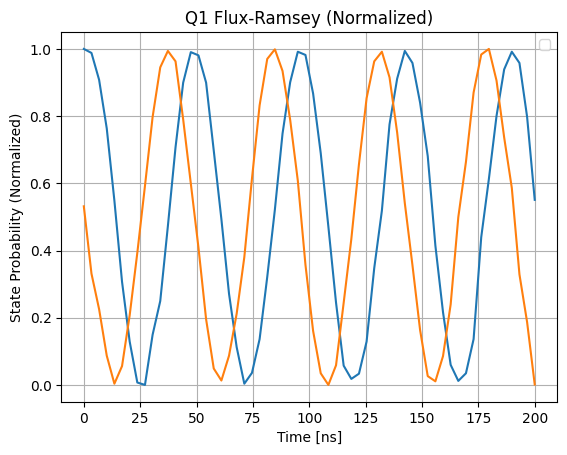

-20002000.200020004
-0.05


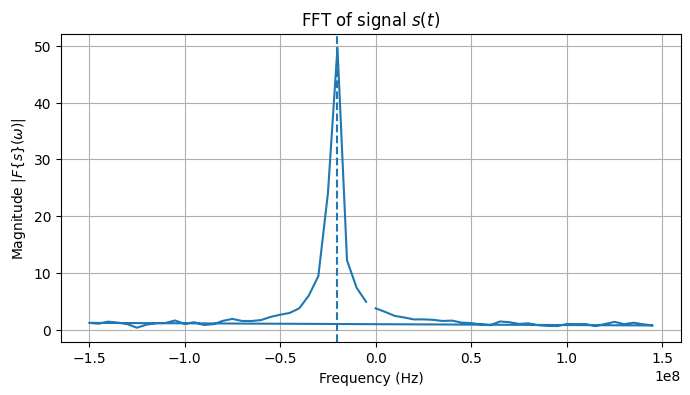

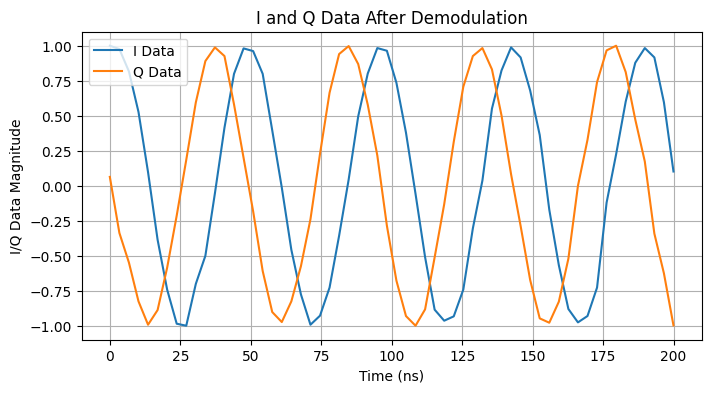

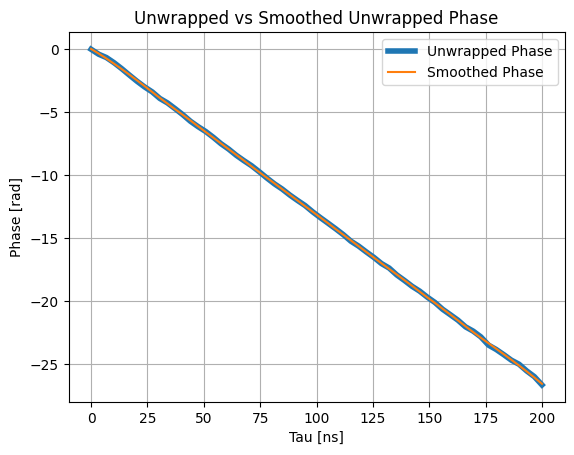

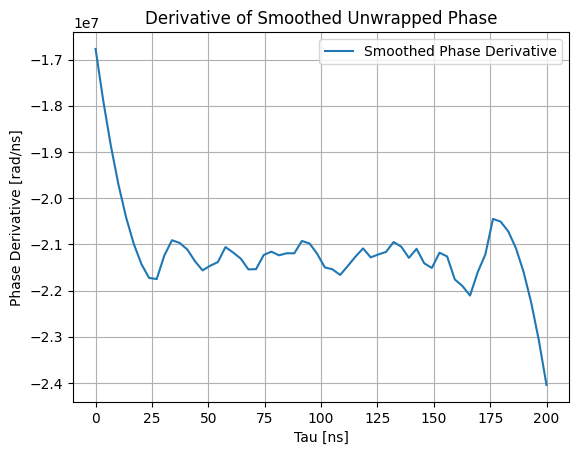

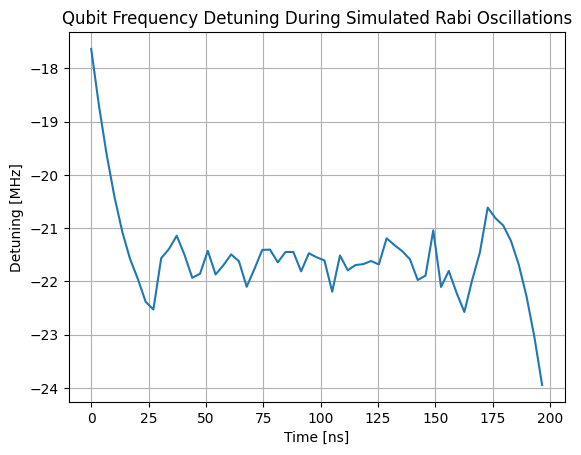

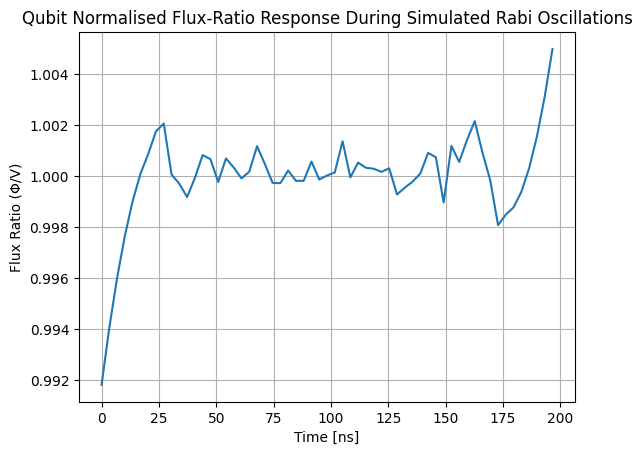

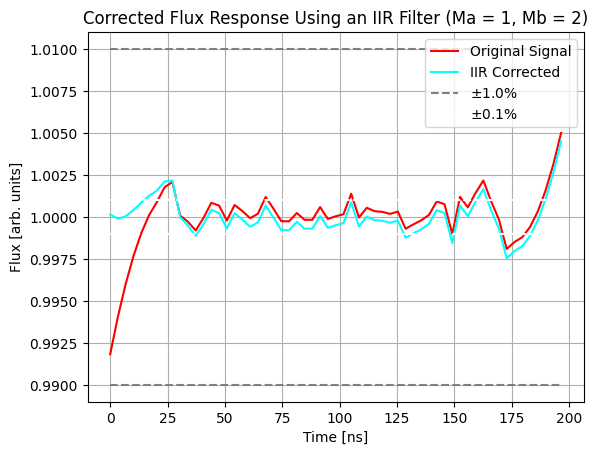

In [44]:
if __name__ == "__main__":

    method_type = 1 # 1 or 2
    IIR_filters = 1 # a non-negative integer
    IIR_order = "full" # 'first' or 'full' --- probs keep this as first
    several_dist = True ### --- keep this as True!
    Mb = 2 # a positive integer --- probs keep these both as 2 in line with a first-order
    Ma = 1 # a positive integer
    FIR_filter = False # True or False
    cutoff = False # True or False --- if True, fir_taps <= 49
    first_filter = 'IIR'
    view_numerics = False
    fir_taps = 28
    P = 1
    compute_and_plot(method_type, IIR_filters, IIR_order, several_dist, Mb, Ma, FIR_filter, cutoff, fir_taps, view_numerics, first_filter, P)


In [430]:
b = np.array([1.06599608e+00, -2.44525691e-02, -1.94324771e-02, -1.52942181e-02,
 -1.14497958e-02, -8.15123455e-03, -4.91697251e-03, -4.28649959e-03,
  1.03638763e-02,  4.51385199e-03,  2.12463240e-03,  4.01181690e-03,
  3.33411722e-03,  4.37492288e-03, -1.56525927e-03,  1.29686677e-03,
  1.57070705e-03, -2.04100180e-03,  2.15540695e-03, -4.94437389e-03,
  1.43032371e-03, -1.91920972e-03, -1.16397979e-03, -9.58530354e-04,
 -1.93708003e-03,  1.54841485e-03, -5.71843271e-04, -2.46817857e-03,
 -2.47824528e-03, -5.47763139e-03, -1.94081112e-03, -5.57001348e-03,
  4.76189035e-04,  3.88653621e-04, -2.34585682e-03,  2.68810173e-03,
 -1.53863019e-03,  4.11802814e-03,  3.31269090e-03,  4.83554767e-04,
  5.08735615e-03, -2.45714522e-03,  4.32748289e-04,  4.93605311e-03,
  6.80045846e-05,  1.47041491e-03,  8.94052070e-03, -6.17379453e-03
])

print(len(b))

48


In [436]:
b = np.fromstring("""
0.07136845  0.04924609  0.03715931  0.02646629  0.02184132  0.01952774
  0.01827935  0.02224588  0.02430184  0.02603129  0.02768208  0.03197887
  0.03358106  0.02976084  0.02392859  0.0227304   0.02097507  0.01997811
  0.02053221  0.02209131  0.02461306  0.0289643   0.03403775  0.03723655
  0.03808082  0.03887234  0.03712203  0.0303989   0.02518484  0.01643583
  0.00991555  0.00554934  0.00370991  0.00052967 -0.00034472  0.00394263
  0.00952457  0.01213472  0.01416198  0.01344459  0.01345458  0.00432026
 -0.0044231  -0.01160362 -0.01760919 -0.00881413  0.01425792  0.05631517
                  """, sep = " ")

print(b)
print(len(b))

[ 0.07136845  0.04924609  0.03715931  0.02646629  0.02184132  0.01952774
  0.01827935  0.02224588  0.02430184  0.02603129  0.02768208  0.03197887
  0.03358106  0.02976084  0.02392859  0.0227304   0.02097507  0.01997811
  0.02053221  0.02209131  0.02461306  0.0289643   0.03403775  0.03723655
  0.03808082  0.03887234  0.03712203  0.0303989   0.02518484  0.01643583
  0.00991555  0.00554934  0.00370991  0.00052967 -0.00034472  0.00394263
  0.00952457  0.01213472  0.01416198  0.01344459  0.01345458  0.00432026
 -0.0044231  -0.01160362 -0.01760919 -0.00881413  0.01425792  0.05631517]
48


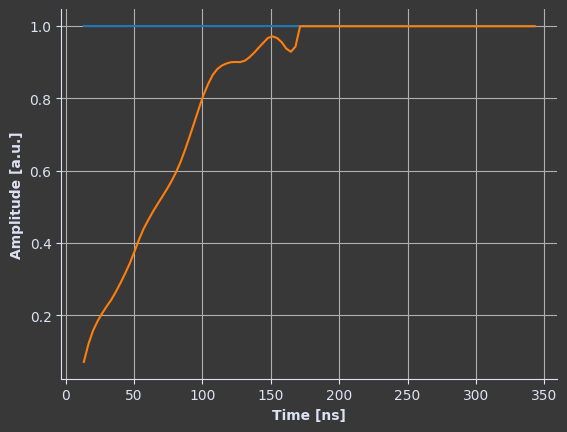

In [437]:
filename = "QData_Cryoscope_Method2_13.3_start_100_shots_amplitude_0.5.npy""NUS Code"
stem = Path(filename).stem

awg_amp = float(stem.split("amplitude_")[1])
start_tau = float(stem.split("Method2_")[1].split("_")[0]) * 10e-10
tau_shots = int(stem.split("start_")[1].split("_")[0])
delta_tau = 3.33e-9 # smallest interval possible 
end_tau = start_tau + tau_shots * delta_tau
tau_sweep = np.linspace(start_tau, end_tau, tau_shots)
bb_awg = np.heaviside(tau_sweep[:-1], 1.0)

filtered = lfilter(b, 1.0, bb_awg)

plt.plot(tau_sweep[:-1] * 1e9, bb_awg, label = 'BB AWG Pulse')
plt.plot(tau_sweep[:-1] * 1e9, filtered, label = 'FIR Corrected')
plt.xlabel('Time [ns]')
plt.ylabel('Amplitude [a.u.]')
plt.grid(True)
plt.show()
